In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score

In [4]:
url_telco = "https://raw.githubusercontent.com/G-Gyra/ProyectoCoderHouse/refs/heads/main/data/Telco_Customer_Churn.csv"

In [5]:
df = pd.read_csv(url_telco)
print("✅ ¡Dataset de Telco cargado con éxito!")

✅ ¡Dataset de Telco cargado con éxito!


In [6]:
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Convertimos TotalCharges a numérico para manejar los espacios en blanco

In [8]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

Eliminamos el CustomerID ya que no lo vamos a necesitar para el analisis que realizaré

In [7]:
df.drop('customerID', axis=1, inplace=True)

Aplicamos LabelEncoder para poder leer las columnas

In [9]:
le = LabelEncoder()
df_encoded = df.apply(lambda col: le.fit_transform(col) if col.dtype == 'object' else col)

Separamos los datos

In [10]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

Usaré SelectKBest con k=10 para elegir las 10 mejores caracteristicas

In [11]:
selector = SelectKBest(score_func=f_classif, k=10)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

In [12]:
selected_features = X.columns[selector.get_support()]
print(f"Variables seleccionadas: {list(selected_features)}")

Variables seleccionadas: ['Dependents', 'tenure', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'Contract', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges']


Como algoritmo de clasificacion utilizaremos random forest

In [13]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_selected, y_train)

RandomForestClassifier(random_state=42)

In [14]:
y_pred = model.predict(X_test_selected)

Por ultimo realizamos el calculo de las metricas basicas, donde 0 representa a los clientes que se quedan y 1 a los churn

In [15]:
print("\n--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred))

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, model.predict_proba(X_test_selected)[:, 1]):.4f}")


--- Reporte de Clasificación ---
              precision    recall  f1-score   support

           0       0.82      0.89      0.85      1549
           1       0.60      0.48      0.53       561

    accuracy                           0.78      2110
   macro avg       0.71      0.68      0.69      2110
weighted avg       0.76      0.78      0.77      2110

Accuracy: 0.7768
ROC-AUC: 0.8036


Matriz de confusion

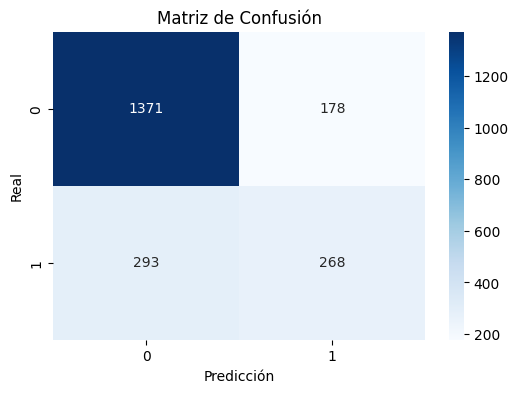

In [16]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

### ***Conclusiones obtenidas a partir del analisis realizado***

La efectividad del modelo alcanzó un Accuracy de 78% y un ROC-AUC de 80%, lo cual indica una capacidad sólida para distinguir entre clientes que se quedan y los que se van. Con un AUC de 0.80, la empresa Telco podría priorizar sus esfuerzos de retención sobre el 20% de los clientes con mayor puntaje de riesgo, capturando a la gran mayoría de los potenciales 'churners' antes de que abandonen el servicio.

Gracias al método de Feature Selection, identificamos que variables como tenure, Contract (tipo de contrato) y MonthlyCharges son los principales predictores del abandono de los clientes.

Se puede observar que los clientes con contratos Month to Month tienen una tasa de fuga mucho mayor. La recomendación es crear incentivos para migrar a estos clientes a contratos anuales.

La matriz de confusión refleja un modelo con un desempeño sólido y equilibrado, sustentado por un ROC AUC del 80% y un Accuracy del 78%. El sistema demuestra una alta especificidad al identificar correctamente a los clientes leales (Verdaderos Negativos), minimizando el riesgo de saturar a los clientes estables con campañas innecesarias. Sin embargo, desde una perspectiva analítica y de negocio, el foco principal reside en la gestión del trade-off entre precisión y sensibilidad: mientras que los Falsos Positivos representan un costo operativo marginal en acciones de retención, los Falsos Negativos constituyen el riesgo crítico de pérdida de clientes no detectados.